In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
from pathlib import Path

project_folder = Path.cwd().parent

file_path = project_folder / "data" / "processed" / "cleaned_sales.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset loaded successfully
Shape: (99863, 11)
Columns:
['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id']


In [3]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Date range:")
print(df["date"].min(), "to", df["date"].max())

print("\nMissing dates:", df["date"].isna().sum())

Date range:
2022-01-01 00:00:00 to 2025-12-31 00:00:00

Missing dates: 0


In [4]:
df["week"] = df["date"].dt.to_period("W-MON").apply(lambda x: x.start_time)

print(df[["date", "sku_id", "quantity", "week"]].head(10))

        date    sku_id  quantity       week
0 2025-04-02  SKU02498         1 2025-04-01
1 2025-04-02  SKU04596         3 2025-04-01
2 2022-04-24  SKU00078         1 2022-04-19
3 2022-04-24  SKU00554         2 2022-04-19
4 2024-09-22  SKU03727         1 2024-09-17
5 2024-09-22  SKU03971         2 2024-09-17
6 2025-10-06  SKU04378         1 2025-09-30
7 2024-12-12  SKU00884         1 2024-12-10
8 2025-12-08  SKU02757         1 2025-12-02
9 2024-01-13  SKU03661         1 2024-01-09


In [5]:
weekly_demand = (
    df.groupby(["week", "sku_id"], as_index=False)
      .agg(
          weekly_quantity=("quantity", "sum"),
          weekly_sales=("total_value", "sum")
      )
)

weekly_demand = weekly_demand.sort_values(
    ["sku_id", "week"]
).reset_index(drop=True)

print("Weekly demand shape:", weekly_demand.shape)

print("\nFirst 20 rows:")
print(weekly_demand.head(20))

Weekly demand shape: (80081, 4)

First 20 rows:
         week    sku_id  weekly_quantity  weekly_sales
0  2022-03-29  SKU00001                1        813.41
1  2022-06-14  SKU00001                2       1626.82
2  2022-07-19  SKU00001                3       2440.23
3  2023-01-17  SKU00001                2       1626.82
4  2023-04-11  SKU00001                5       4067.05
5  2023-05-16  SKU00001                1        813.41
6  2023-07-18  SKU00001                1        813.41
7  2023-08-01  SKU00001                1        813.41
8  2023-08-15  SKU00001                4       3253.64
9  2023-11-07  SKU00001                2       1626.82
10 2023-11-21  SKU00001                2       1626.82
11 2023-12-12  SKU00001                1        813.41
12 2024-01-02  SKU00001                2       1626.82
13 2024-03-19  SKU00001                2       1626.82
14 2024-08-06  SKU00001                1        813.41
15 2024-11-26  SKU00001                2       1626.82
16 2024-12-31  SK

In [6]:
print("Number of unique SKUs:", weekly_demand["sku_id"].nunique())

print("\nNumber of weeks:",
      weekly_demand["week"].nunique())

print("\nDate range:")
print(
    weekly_demand["week"].min(),
    "to",
    weekly_demand["week"].max()
)

Number of unique SKUs: 4998

Number of weeks: 210

Date range:
2021-12-28 00:00:00 to 2025-12-30 00:00:00


In [7]:
all_weeks = pd.date_range(
    weekly_demand["week"].min(),
    weekly_demand["week"].max(),
    freq="7D"
)

all_skus = weekly_demand["sku_id"].unique()

complete_index = pd.MultiIndex.from_product(
    [all_weeks, all_skus],
    names=["week", "sku_id"]
)

weekly_complete = (
    weekly_demand
    .set_index(["week", "sku_id"])
    .reindex(complete_index)
    .reset_index()
)

In [8]:
print("Missing weekly quantities:",
      weekly_complete["weekly_quantity"].isna().sum())

Missing weekly quantities: 969499


In [9]:
weekly_complete["weekly_quantity"] = (
    weekly_complete["weekly_quantity"].fillna(0)
)

weekly_complete["weekly_sales"] = (
    weekly_complete["weekly_sales"].fillna(0)
)

print("Missing values after filling:")
print(weekly_complete.isna().sum())

Missing values after filling:
week               0
sku_id             0
weekly_quantity    0
weekly_sales       0
dtype: int64


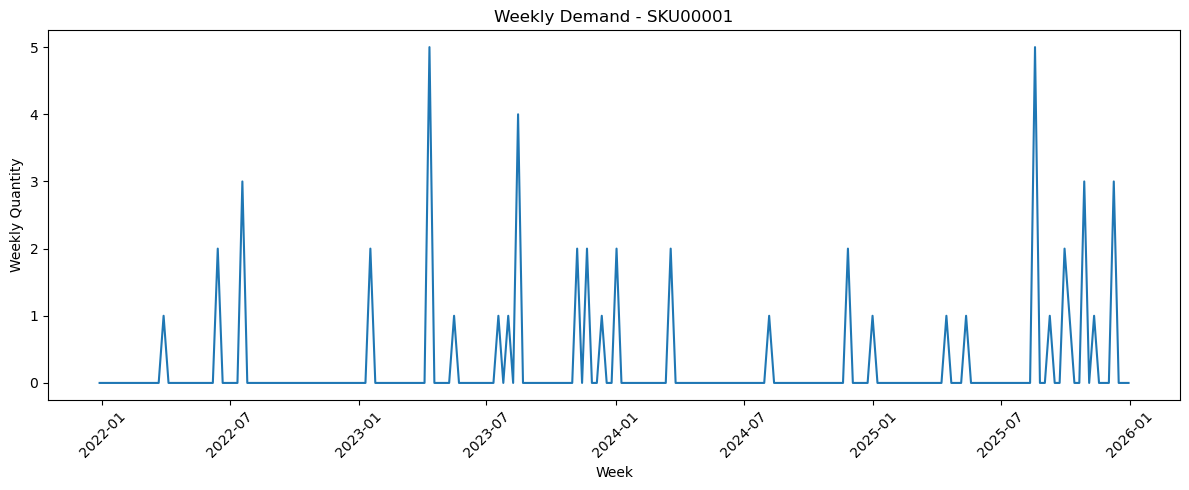

In [10]:
sample_sku = weekly_complete["sku_id"].iloc[0]

sku_data = weekly_complete[
    weekly_complete["sku_id"] == sample_sku
]

plt.figure(figsize=(12, 5))

plt.plot(
    sku_data["week"],
    sku_data["weekly_quantity"]
)

plt.title(f"Weekly Demand - {sample_sku}")
plt.xlabel("Week")
plt.ylabel("Weekly Quantity")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
sku_demand_summary = (
    weekly_complete
    .groupby("sku_id", as_index=False)
    .agg(
        total_quantity=("weekly_quantity", "sum"),
        average_weekly_demand=("weekly_quantity", "mean"),
        max_weekly_demand=("weekly_quantity", "max")
    )
    .sort_values("total_quantity", ascending=False)
)

print(sku_demand_summary.head(10))

        sku_id  total_quantity  average_weekly_demand  max_weekly_demand
4318  SKU04321         12156.0              57.885714              120.0
4593  SKU04596          2821.0              13.433333               37.0
3724  SKU03727          1810.0               8.619048               28.0
4151  SKU04154          1347.0               6.414286               28.0
952   SKU00953          1173.0               5.585714               24.0
993   SKU00994          1004.0               4.780952               16.0
3289  SKU03292           997.0               4.747619               18.0
2139  SKU02141           988.0               4.704762               23.0
189   SKU00190           948.0               4.514286               16.0
1773  SKU01775           790.0               3.761905               16.0


In [12]:
weekly_demand_final = weekly_complete[
    ["week", "sku_id", "weekly_quantity"]
].copy()

weekly_demand_final = weekly_demand_final.sort_values(
    ["sku_id", "week"]
).reset_index(drop=True)

print(weekly_demand_final.head(20))
print("\nShape:", weekly_demand_final.shape)

         week    sku_id  weekly_quantity
0  2021-12-28  SKU00001              0.0
1  2022-01-04  SKU00001              0.0
2  2022-01-11  SKU00001              0.0
3  2022-01-18  SKU00001              0.0
4  2022-01-25  SKU00001              0.0
5  2022-02-01  SKU00001              0.0
6  2022-02-08  SKU00001              0.0
7  2022-02-15  SKU00001              0.0
8  2022-02-22  SKU00001              0.0
9  2022-03-01  SKU00001              0.0
10 2022-03-08  SKU00001              0.0
11 2022-03-15  SKU00001              0.0
12 2022-03-22  SKU00001              0.0
13 2022-03-29  SKU00001              1.0
14 2022-04-05  SKU00001              0.0
15 2022-04-12  SKU00001              0.0
16 2022-04-19  SKU00001              0.0
17 2022-04-26  SKU00001              0.0
18 2022-05-03  SKU00001              0.0
19 2022-05-10  SKU00001              0.0

Shape: (1049580, 3)


In [13]:
output_path = project_folder / "data" / "processed" / "weekly_demand.csv"

weekly_demand_final.to_csv(
    output_path,
    index=False
)

print("Weekly demand file saved:")
print(output_path)

Weekly demand file saved:
C:\Users\Deepak\Desktop\FORESIGHT PROJECT\data\processed\weekly_demand.csv


In [14]:
print("=" * 60)
print("WEEKLY DEMAND DATA VALIDATION")
print("=" * 60)

print("Rows:", len(weekly_demand_final))
print("SKUs:", weekly_demand_final["sku_id"].nunique())
print("Weeks:", weekly_demand_final["week"].nunique())

print("\nMissing values:")
print(weekly_demand_final.isna().sum())

print("\nDuplicate Week-SKU combinations:")
print(
    weekly_demand_final.duplicated(
        ["week", "sku_id"]
    ).sum()
)

print("\nWeekly demand statistics:")
print(
    weekly_demand_final["weekly_quantity"].describe()
)

WEEKLY DEMAND DATA VALIDATION
Rows: 1049580
SKUs: 4998
Weeks: 210

Missing values:
week               0
sku_id             0
weekly_quantity    0
dtype: int64

Duplicate Week-SKU combinations:
0

Weekly demand statistics:
count    1.049580e+06
mean     1.791517e-01
std      1.128797e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.200000e+02
Name: weekly_quantity, dtype: float64


In [15]:
weekly = pd.read_csv("../data/processed/weekly_demand.csv")

weekly.head()

,week,sku_id,weekly_quantity
0,2021-12-28,SKU00001,0.0
1,2022-01-04,SKU00001,0.0
2,2022-01-11,SKU00001,0.0
3,2022-01-18,SKU00001,0.0
4,2022-01-25,SKU00001,0.0


In [16]:
weekly["week"] = pd.to_datetime(weekly["week"])

weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1049580 entries, 0 to 1049579
Data columns (total 3 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   week             1049580 non-null  datetime64[ns]
 1   sku_id           1049580 non-null  object        
 2   weekly_quantity  1049580 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 24.0+ MB


In [17]:
weekly["week"] = pd.to_datetime(weekly["week"])

print("Minimum week:", weekly["week"].min())
print("Maximum week:", weekly["week"].max())

Minimum week: 2021-12-28 00:00:00
Maximum week: 2025-12-30 00:00:00


In [18]:
# Seasonal period
SEASONAL_WEEKS = 52

print("Seasonal period:", SEASONAL_WEEKS, "weeks")

Seasonal period: 52 weeks


In [19]:
# Test period: 2025
TEST_YEAR = 2025

test = weekly[weekly["week"].dt.year == TEST_YEAR].copy()

print("Test period:")
print(test["week"].min())
print(test["week"].max())

print("\nRows:", len(test))
print("SKUs:", test["sku_id"].nunique())

Test period:
2025-01-07 00:00:00
2025-12-30 00:00:00

Rows: 259896
SKUs: 4998


In [20]:
# Create seasonal-naive baseline forecast
# 2025 forecast = corresponding 2024 demand

history = weekly[
    weekly["week"].dt.year == TEST_YEAR - 1
][["week", "sku_id", "weekly_quantity"]].copy()

history["forecast_week"] = history["week"] + pd.Timedelta(weeks=52)

history = history.rename(
    columns={"weekly_quantity": "baseline_forecast"}
)

baseline = test.merge(
    history[["forecast_week", "sku_id", "baseline_forecast"]],
    left_on=["week", "sku_id"],
    right_on=["forecast_week", "sku_id"],
    how="left"
)

baseline = baseline.drop(columns=["forecast_week"])

print("Baseline rows:", len(baseline))
print("Missing forecasts:", baseline["baseline_forecast"].isna().sum())

baseline.head()

Baseline rows: 259896
Missing forecasts: 0


,week,sku_id,weekly_quantity,baseline_forecast
0,2025-01-07,SKU00001,0.0,0.0
1,2025-01-14,SKU00001,0.0,0.0
2,2025-01-21,SKU00001,0.0,0.0
3,2025-01-28,SKU00001,0.0,0.0
4,2025-02-04,SKU00001,0.0,0.0


In [21]:
# Calculate Seasonal-Naive Baseline WAPE

import numpy as np

baseline["absolute_error"] = (
    baseline["weekly_quantity"] - baseline["baseline_forecast"]
).abs()

wape = (
    baseline["absolute_error"].sum()
    / baseline["weekly_quantity"].abs().sum()
) * 100

print("Seasonal-Naive Baseline WAPE:", round(wape, 2), "%")

Seasonal-Naive Baseline WAPE: 156.65 %


In [22]:
print("Total Actual Demand:",
      baseline["weekly_quantity"].sum())

print("Total Baseline Forecast:",
      baseline["baseline_forecast"].sum())

print("Total Absolute Error:",
      baseline["absolute_error"].sum())

Total Actual Demand: 49359.0
Total Baseline Forecast: 48101.0
Total Absolute Error: 77320.0


In [23]:
sku_wape = (
    baseline.groupby("sku_id")
    .apply(
        lambda x: (
            x["weekly_quantity"] - x["baseline_forecast"]
        ).abs().sum()
        / x["weekly_quantity"].abs().sum()
        * 100
            if x["weekly_quantity"].abs().sum() != 0
            else np.nan
    )
    .reset_index(name="wape")
)

sku_wape.head()

C:\Users\Deepak\AppData\Local\Temp\ipykernel_2256\1802474317.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,sku_id,wape
0,SKU00001,133.333333
1,SKU00002,128.971963
2,SKU00003,100.000000
3,SKU00004,233.333333
4,SKU00005,155.555556


In [24]:
print("Number of SKUs:", sku_wape["sku_id"].nunique())

print("\nBest performing SKUs:")
print(sku_wape.sort_values("wape").head(10))

print("\nWorst performing SKUs:")
print(sku_wape.sort_values("wape", ascending=False).head(10))

Number of SKUs: 4998

Best performing SKUs:
        sku_id       wape
3775  SKU03778  25.000000
4318  SKU04321  28.453215
3034  SKU03036  33.333333
3089  SKU03091  42.857143
3724  SKU03727  47.121535
732   SKU00733  50.000000
2631  SKU02633  50.000000
4551  SKU04554  50.000000
1038  SKU01039  50.000000
1861  SKU01863  50.000000

Worst performing SKUs:
        sku_id    wape
2883  SKU02885  2000.0
4452  SKU04455  1700.0
1937  SKU01939  1700.0
4022  SKU04025  1600.0
2599  SKU02601  1600.0
1385  SKU01386  1600.0
4697  SKU04700  1500.0
1538  SKU01539  1500.0
3967  SKU03970  1400.0
777   SKU00778  1400.0


In [25]:
# Final Seasonal-Naive Baseline Summary

print("========== SEASONAL-NAIVE BASELINE SUMMARY ==========")

print("Test Period:")
print(
    baseline["week"].min().strftime("%Y-%m-%d"),
    "to",
    baseline["week"].max().strftime("%Y-%m-%d")
)

print("\nSeasonal Period:", SEASONAL_WEEKS, "weeks")

print("\nTotal Actual Demand:",
      round(baseline["weekly_quantity"].sum(), 2))

print("Total Baseline Forecast:",
      round(baseline["baseline_forecast"].sum(), 2))

print("Total Absolute Error:",
      round(baseline["absolute_error"].sum(), 2))

print("Overall WAPE:",
      round(wape, 2), "%")

print("Number of SKUs:",
      baseline["sku_id"].nunique())

print("Missing Forecasts:",
      baseline["baseline_forecast"].isna().sum())

========== SEASONAL-NAIVE BASELINE SUMMARY ==========
Test Period:
2025-01-07 to 2025-12-30

Seasonal Period: 52 weeks

Total Actual Demand: 49359.0
Total Baseline Forecast: 48101.0
Total Absolute Error: 77320.0
Overall WAPE: 156.65 %
Number of SKUs: 4998
Missing Forecasts: 0


# FINAL D3 BASELINE HANDOFF
The baseline below is retained as a separately reproducible reference. The final model evaluation is performed in the corrected model notebook.

In [26]:
# Final baseline validation
assert "baseline" in globals() and not baseline.empty
assert "baseline_forecast" in baseline.columns
assert baseline["baseline_forecast"].notna().all(), "Baseline contains missing forecasts."
assert "wape" in globals() and pd.notna(wape)
print("Seasonal-naive baseline handoff: PASS")
print(f"WAPE: {wape:.2f}%")

Seasonal-naive baseline handoff: PASS
WAPE: 156.65%
